In [5]:
import os
import librosa
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

def split_audio_into_seconds(audio_file, segment_duration=1, output_folder="adult_lobsters"):
  """
  Splits an audio file into 1-second segments and saves them to a specified folder.

  Args:
    audio_file: Path to the audio file.
    segment_duration: Duration of each segment in seconds (default: 1 second).
    output_folder: Path to the output folder where segments will be saved. 

  Returns:
    None
  """

  # Create the output folder if it doesn't exist
  os.makedirs(output_folder, exist_ok=True) 

  y, sr = librosa.load(audio_file)
  samples_per_segment = int(sr * segment_duration)

  for i in range(0, len(y), samples_per_segment):
    segment = y[i:i + samples_per_segment]
    if len(segment) < samples_per_segment:
      # Pad the last segment with zeros to ensure consistent length
      segment = np.pad(segment, (0, samples_per_segment - len(segment)), 'constant') 
    segment_filename = os.path.join(output_folder, f"segment_{i // samples_per_segment}.wav") 
    sf.write(segment_filename, segment, sr)

# Example usage:
audio_file_path = "female_lobsters.wav" 
output_directory = "female_losbters"  # Create a folder named "audio_segments"
split_audio_into_seconds(audio_file_path, output_folder=output_directory)

22050
22050


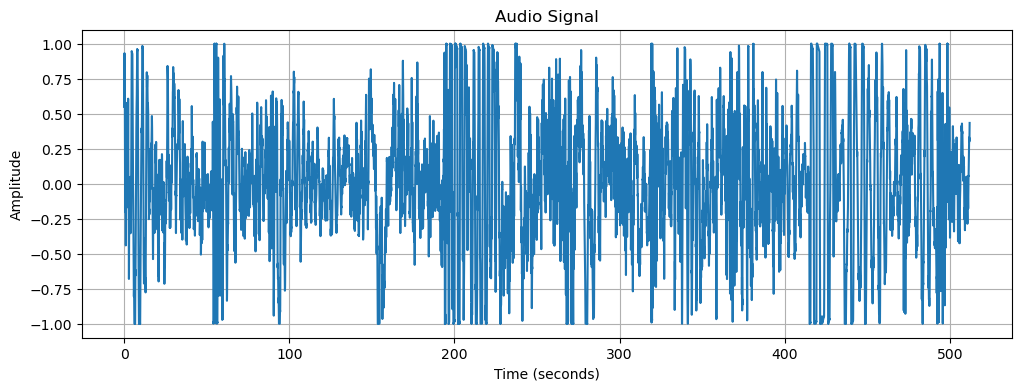

In [6]:
import librosa
import matplotlib.pyplot as plt

# Load the audio file
y1, sr1 = librosa.load('female_losbters/segment_1.wav') 

# y: Audio time series (numpy array)
# sr: Sampling rate (in Hz)

print(len(y1)) 
print(sr1) 
# Create time array
t1 = librosa.times_like(y1) 

# Plot the audio signal
plt.figure(figsize=(12, 4))
plt.plot(t1, y1)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Audio Signal')
plt.grid(True)
plt.show()

22050


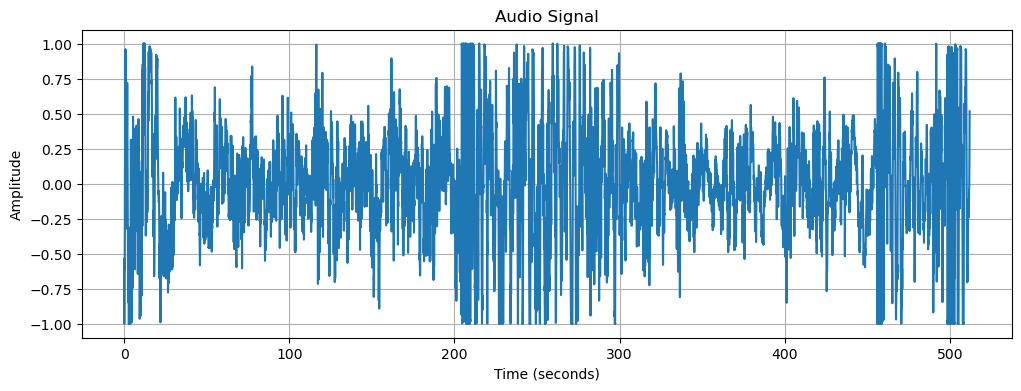

In [7]:
import librosa
import matplotlib.pyplot as plt

# Load the audio file
y2, sr2 = librosa.load('female_losbters/segment_0.wav') 

# y: Audio time series (numpy array)
# sr: Sampling rate (in Hz)

print(len(y2)) 
#print(sr2) 
# Create time array
t2 = librosa.times_like(y2) 

# Plot the audio signal
plt.figure(figsize=(12, 4))
plt.plot(t2, y2)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Audio Signal')
plt.grid(True)
plt.show()

Number of files in 'female_lobsters': 2900
Number of files in 'male_lobsters': 4500
Number of files in 'adult_lobsters': 5000
Number of files in 'juvenile_lobsters': 2400


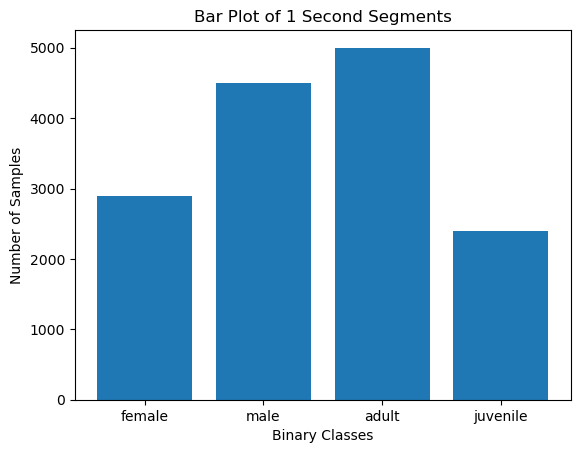

In [8]:
import os
import matplotlib.pyplot as plt


def count_files_in_directory(directory):
  """
  Counts the number of files within a given directory.

  Args:
    directory: The path to the directory.

  Returns:
    The number of files in the directory.
  """
  file_count = 0
  for root, dirs, files in os.walk(directory):
    file_count += len(files)
  return file_count

# Example usage:
directory_path2 = 'male_lobsters'
directory_path1 = 'female_lobsters'  # Replace with the actual directory path
directory_path3 = 'adult_lobsters'
directory_path4 = 'juvenile_lobsters'
num_files1 = count_files_in_directory(directory_path1)
num_files2 = count_files_in_directory(directory_path2)
num_files3 = count_files_in_directory(directory_path3)
num_files4 = count_files_in_directory(directory_path4)

print(f"Number of files in '{directory_path1}': {num_files1}")
print(f"Number of files in '{directory_path2}': {num_files2}")
print(f"Number of files in '{directory_path3}': {num_files3}")
print(f"Number of files in '{directory_path4}': {num_files4}")

# Data
x_labels = ["female", "male", "adult", "juvenile"]
y_values = [num_files1, num_files2, num_files3, num_files4]

# Create the bar plot
plt.bar(x_labels, y_values)

# Customize the plot
plt.xlabel("Binary Classes")
plt.ylabel("Number of Samples")
plt.title("Bar Plot of 1 Second Segments")

# Show the plot
plt.show()


In [12]:
import os
import librosa
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score, f1_score
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import time

# Define paths to the folders
folder1_path = 'adult_lobsters'  # Replace with the actual path to folder 1
folder2_path = 'juvenile_lobsters'  # Replace with the actual path to folder 2

# Define parameters
sample_rate = 22050
n_fft = 2048
hop_length = 512
num_classes = 2  # Binary classification

# Load audio data and create labels
def load_data(folder_path):
    X = []
    y = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".wav"):  # Assuming WAV files
            file_path = os.path.join(folder_path, filename)
            audio, _ = librosa.load(file_path, sr=sample_rate)
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
            X.append(mfccs.T)  # Transpose for Conv1D input
            y.append(1 if folder_path == folder1_path else 0)  # Label 1 for folder1, 0 for folder2
    return np.array(X), np.array(y)

# Load data for both folders
X1, y1 = load_data(folder1_path)
X2, y2 = load_data(folder2_path)

# Combine data from both folders
X = np.concatenate((X1, X2), axis=0)
y = np.concatenate((y1, y2), axis=0)

seed_value = 42
np.random.seed(seed_value)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value)


# Create 1D CNN model with variable number of layers
def create_model(num_layers):
    model = Sequential()
    for i in range(num_layers):
        model.add(Conv1D(filters=32, kernel_size=3, activation='relu', 
                         input_shape=(X_train.shape[1], X_train.shape[2]) if i == 0 else None))
        model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    return model

# Example usage:
num_layers = 3  # Change this value to experiment with different numbers of layers
model = create_model(num_layers)

# ... (Rest of your code: compile, train, evaluate) ...

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary() 

#Early Stopping
#early_stopping = EarlyStopping(monitor='val_accuracy', patience=5)

# Train the model
history = model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_test, y_test))#, callbacks=[early_stopping])


# Evaluate the model
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_labels)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred_labels, average='weighted')
print("Precision:", precision)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)
print("Confusion Matrix:\n", cm)

recall = recall_score(y_test, y_pred_labels) 
print(f"Recall: {recall}") 

# Calculate F1-score for binary classification
f1_binary = f1_score(y_test, y_pred_labels) 
#print(f"F1-score (binary): {f1_binary}")

###mAP50 Begins here


# Create the mAP@0.5 metric
#map50 = tf.keras.metrics.MeanAveragePrecision(num_classes=num_classes, top_k=50, iou_threshold=0.5) 

# Evaluate the model
#loss, accuracy, map50_score = model.evaluate(x_test, y_test)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
##print(f"mAP@0.5: {map50_score:.4f}")



def measure_inference_time(model, input_data, num_runs=100):
  """
  Measures the average inference time of a given model.

  Args:
    model: The trained model to be evaluated.
    input_data: A sample input for the model.
    num_runs: The number of times to run inference for averaging.

  Returns:
    The average inference time in seconds.
  """

  total_time = 0.0

  for _ in range(num_runs):
    start_time = time.time()
    _ = model(input_data)  # Run inference
    end_time = time.time()
    total_time += end_time - start_time

  average_time = total_time / num_runs

  return average_time

# Example Usage:
# Assuming you have a trained model (e.g., 'model') and some sample input data ('input_data')
input_data = X_test
average_inference_time = measure_inference_time(model, input_data) 
print(f"Average Inference Time: {average_inference_time:.6f} seconds") 


# Extract training and validation accuracy from history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Create an array of epochs
epochs = range(1, len(train_acc) + 1)

# Plot the accuracy
plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show() 


#Cross-validation computation
# Define K-fold cross-validation
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Define a function to create the Keras model
#def create_model():
    #model = Sequential([
        #Dense(64, activation='relu', input_shape=(X.shape[1],)),
        #Dense(32, activation='relu'),
       # Dense(1, activation='sigmoid')  # Binary classification
    #])
    #model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    #return model

# Perform cross-validation
fold = 1
all_fold_scores = []
for train_index, val_index in kf.split(X):
    print(f"Training on fold {fold}...")
    fold += 1

    # Split data
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Create and train the model
    #model = create_model()
    #model = svm_model
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0, validation_data=(X_val, y_val))
    
    # Evaluate the model
    scores = model.evaluate(X_val, y_val, verbose=0)
    print(f"Validation accuracy: {scores[1]}")
    all_fold_scores.append(scores[1])

# Print the average score across all folds
print(f"Average validation accuracy: {np.mean(all_fold_scores):.2f}")

/home/feliciano/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 42, 32)         │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 21, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 19, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 7, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,834 (81.38 KB)

 Trainable params: 20,834 (81.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7717 - loss: 0.7129 - val_accuracy: 0.9122 - val_loss: 0.2180
Epoch 2/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9069 - loss: 0.2269 - val_accuracy: 0.9345 - val_loss: 0.1764
Epoch 3/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9335 - loss: 0.1542 - val_accuracy: 0.9399 - val_loss: 0.1696
Epoch 4/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9431 - loss: 0.1474 - val_accuracy: 0.9439 - val_loss: 0.1434
Epoch 5/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9476 - loss: 0.1275 - val_accuracy: 0.9270 - val_loss: 0.1687
Epoch 6/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9542 - loss: 0.1195 - val_accuracy: 0.9324 - val_loss: 0.1994
Epoch 7/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9491 - loss: 0.1285 - val_accuracy: 0.9541 - val_loss: 0.1347
Epoch 8/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9665 - loss: 0.0924 - val_accuracy: 0.

NameError: name 'loss' is not defined

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Cross Validation Imports
import numpy as np
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
#Cross Validation Imports


# Define parameters
sample_rate = 22050
n_fft = 2048
hop_length = 512
num_classes = 2  # Binary classification

# Load audio data and create labels
def load_data(folder_path):
    X = []
    y = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".wav"):  # Assuming WAV files
            file_path = os.path.join(folder_path, filename)
            audio, _ = librosa.load(file_path, sr=sample_rate)
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
            X.append(mfccs.T)  # Transpose for Conv1D input
            y.append(1 if folder_path == folder1_path else 0)  # Label 1 for folder1, 0 for folder2
    return np.array(X), np.array(y)

# Load data for both folders
X1, y1 = load_data(folder1_path)
X2, y2 = load_data(folder2_path)

# Combine data from both folders
X = np.concatenate((X1, X2), axis=0)
y = np.concatenate((y1, y2), axis=0)

X_reshaped = X.reshape(X.shape[0], -1)  # Shape: (3, 10)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

# Create and train models
svm_model = SVC(kernel='linear')  # You can try different kernels (e.g., 'rbf', 'poly')
knn_model = KNeighborsClassifier(n_neighbors=5)  # Adjust n_neighbors as needed
dt_model = DecisionTreeClassifier(random_state=42)
#lr_model = LogisticRegression(max_iter=1000)  # Increase max_iter if needed
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) 

# Train and evaluate each model
svm_accuracy = train_and_evaluate_model(svm_model, X_train, y_train, X_test, y_test)
knn_accuracy = train_and_evaluate_model(knn_model, X_train, y_train, X_test, y_test)
dt_accuracy = train_and_evaluate_model(dt_model, X_train, y_train, X_test, y_test)
#lr_accuracy = train_and_evaluate_model(lr_model, X_train, y_train, X_test, y_test)
rf_accuracy = train_and_evaluate_model(rf_model, X_train, y_train, X_test, y_test)

# Print the accuracies
print("SVM Accuracy:", svm_accuracy)
print("KNN Accuracy:", knn_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
#print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)



SVM Accuracy: 0.8891891891891892
KNN Accuracy: 0.8844594594594595
Decision Tree Accuracy: 0.8222972972972973
Random Forest Accuracy: 0.9337837837837838
Training on fold 1...


TypeError: BaseLibSVM.fit() got an unexpected keyword argument 'epochs'

In [39]:
import os
import librosa
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix


# Define paths to the folders
folder1_path = 'female_lobsters'  # Replace with the actual path to folder 1
folder2_path = 'male_lobsters'  # Replace with the actual path to folder 2

# Define parameters
sample_rate = 22050
n_fft = 2048
hop_length = 512
num_classes = 2  # Binary classification

# Load audio data and create labels
def load_data(folder_path):
    X = []
    y = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".wav"):  # Assuming WAV files
            file_path = os.path.join(folder_path, filename)
            audio, _ = librosa.load(file_path, sr=sample_rate)
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
            X.append(mfccs.T)  # Transpose for Conv1D input
            y.append(1 if folder_path == folder1_path else 0)  # Label 1 for folder1, 0 for folder2
    return np.array(X), np.array(y)

# Load data for both folders
X1, y1 = load_data(folder1_path)
X2, y2 = load_data(folder2_path)

# Combine data from both folders
X = np.concatenate((X1, X2), axis=0)
y = np.concatenate((y1, y2), axis=0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create 1D CNN model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary() 

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_labels)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred_labels, average='weighted')
print("Precision:", precision)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)
print("Confusion Matrix:\n", cm)

/home/feliciano/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 42, 32)         │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 21, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 19, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,274 (321.38 KB)

 Trainable params: 82,274 (321.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6665 - loss: 2.3284 - val_accuracy: 0.7932 - val_loss: 0.4862
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8122 - loss: 0.4721 - val_accuracy: 0.8331 - val_loss: 0.3782
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8534 - loss: 0.3389 - val_accuracy: 0.8784 - val_loss: 0.2929
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8855 - loss: 0.2728 - val_accuracy: 0.8770 - val_loss: 0.2866
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9112 - loss: 0.2121 - val_accuracy: 0.8473 - val_loss: 0.3582
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9224 - loss: 0.1903 - val_accuracy: 0.9054 - val_loss: 0.2374
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9297 - loss: 0.1650 - val_accuracy: 0.8905 - val_loss: 0.2559
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9468 - loss: 0.1388 - val_accuracy: 0.